In [114]:
def pad(arr, target=(1000, 1000)):
    h, w = arr.shape
    target_h, target_w = target
    if h >= target_h and w >= target_w:
        return arr
    pad_h = (target_h - h) // 2
    pad_w = (target_w - w) // 2
    padded_arr = np.pad(
        arr,
        ((pad_h, target_h - h - pad_h), (pad_w, target_w - w - pad_w)),
        mode="constant",
        constant_values=0,
    )
    return padded_arr

In [120]:
import freetype
import numpy as np

font_path = "../fonts/字悦九叠印篆.ttf"  # 替换为你的字体路径
face = freetype.Face(font_path)
face.set_pixel_sizes(0, face.units_per_EM)
face.load_char("爽", freetype.FT_LOAD_RENDER | freetype.FT_LOAD_NO_HINTING)

bmp = face.glyph.bitmap
mask = np.array(bmp.buffer).reshape(bmp.rows, bmp.width) > 0
mask = pad(mask)

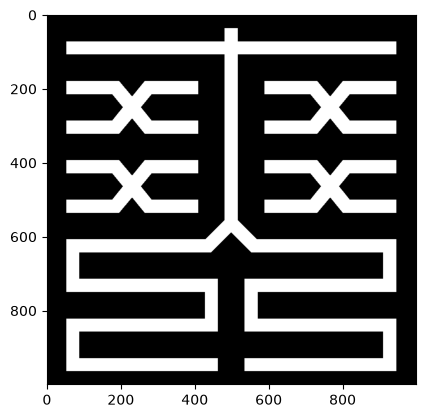

In [121]:
import matplotlib.pyplot as plt

plt.imshow(mask, cmap="gray")

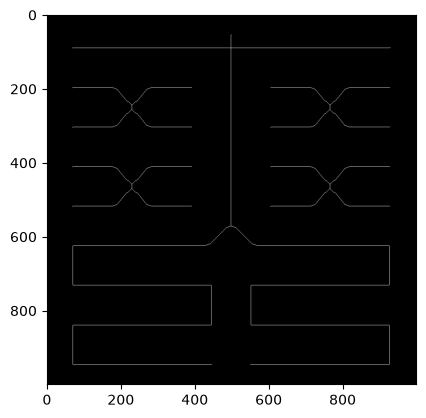

In [142]:
from skimage.morphology import skeletonize, medial_axis

skeleton = skeletonize(mask)
plt.imshow(skeleton, cmap="gray")

## Heuristic 1: co-dilation of positive and negative skeletons and find the meet point

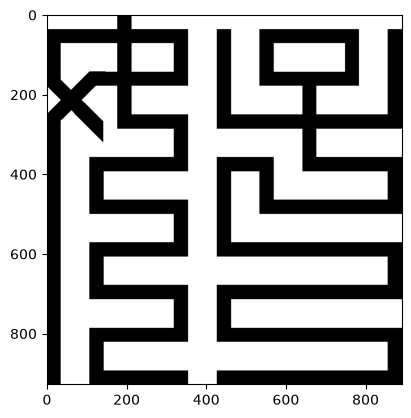

In [12]:
negative = ~mask
plt.imshow(negative, cmap="gray")

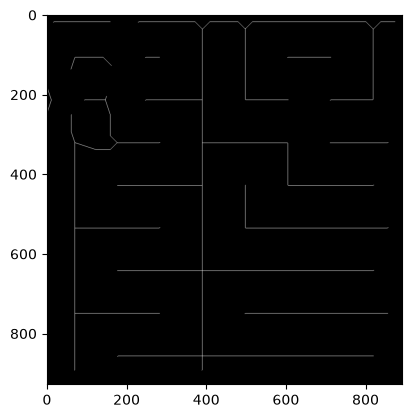

In [14]:
negative_skeleton = skeletonize(negative)
# negative_skeleton = medial_axis(negative, return_distance=False)
plt.imshow(negative_skeleton, cmap="gray")

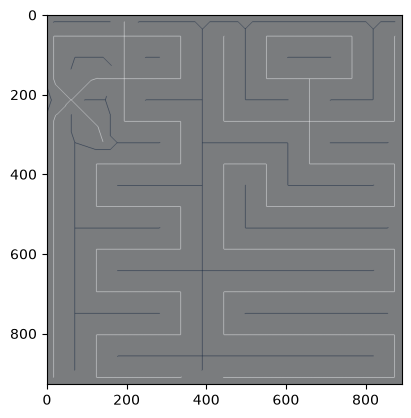

In [41]:
plt.imshow(skeleton, cmap="gray")
plt.imshow(negative_skeleton, cmap="Blues", alpha=0.5)

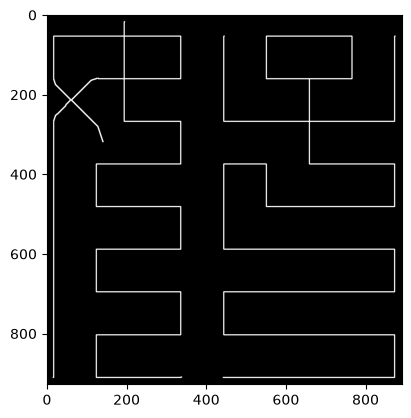

In [42]:
from scipy.ndimage import binary_dilation

kernel = np.ones((3, 3), dtype=bool)
dilated_skeleton = binary_dilation(skeleton, structure=kernel)
plt.imshow(dilated_skeleton, cmap="gray")

7


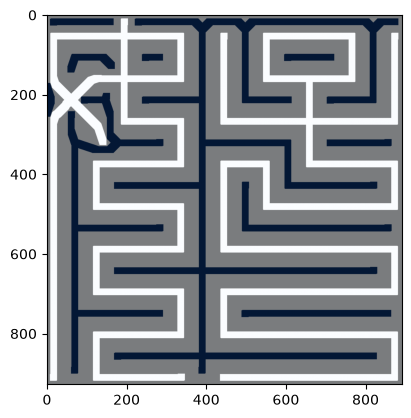

In [44]:
# dilate skeleton and negative skeleton at the same time, pixel by pixel, until two dilated skeletons touch each other.

width = 0
dilated_skeleton = skeleton.copy()
dilated_negative_skeleton = negative_skeleton.copy()
while True:
    dilated_skeleton = binary_dilation(dilated_skeleton, structure=kernel)
    dilated_negative_skeleton = binary_dilation(
        dilated_negative_skeleton, structure=kernel
    )
    overlap = np.logical_and(dilated_skeleton, dilated_negative_skeleton)
    if np.any(overlap):
        break
    width += 1
print(width)
plt.imshow(dilated_skeleton, cmap="gray")
plt.imshow(dilated_negative_skeleton, cmap="Blues", alpha=0.5)

conclusion: not good at skew lines.

## Heuristic 2: correct all strokes to strictly four directions: horizontal, vertical, diagonal and anti-diagonal.

In [140]:
skeleton = mask

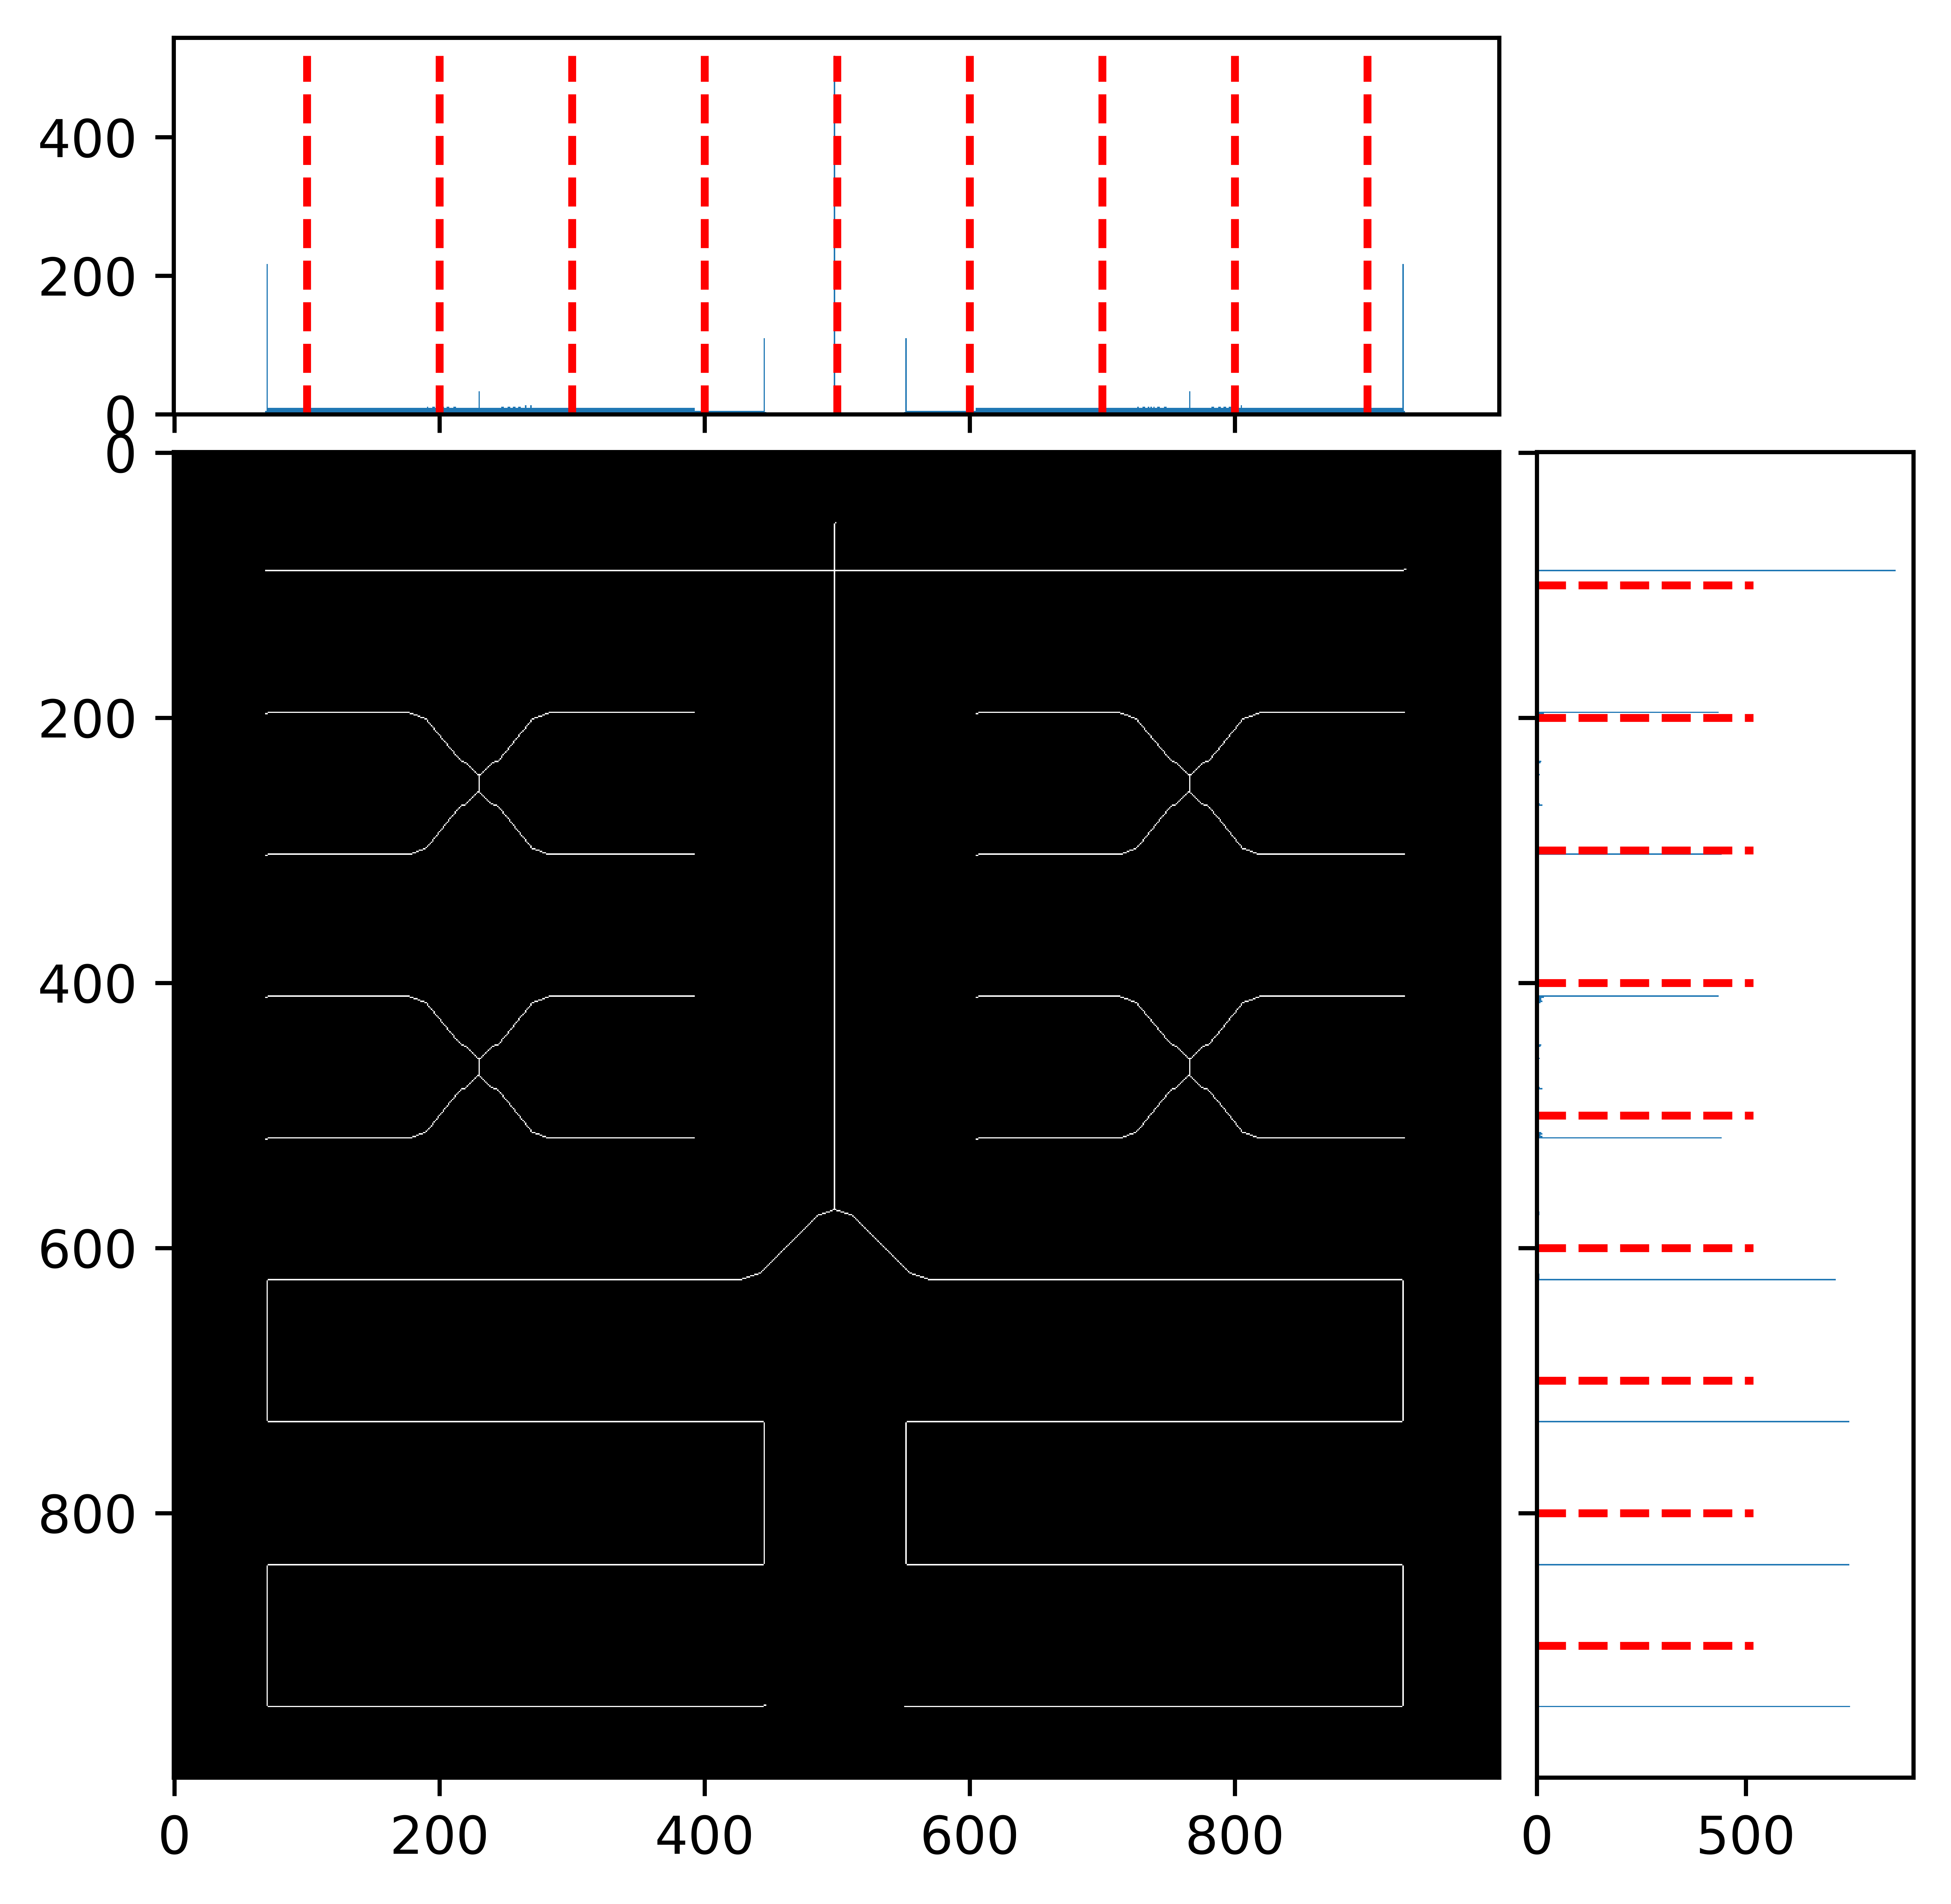

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

ys, xs = np.where(skeleton)

fig, ax = plt.subplots(figsize=(6, 6), dpi=1000)
ax.imshow(skeleton, cmap="gray")  # 默认 origin='upper'

divider = make_axes_locatable(ax)
ax_top = divider.append_axes("top", size=1.0, pad=0.1, sharex=ax)
ax_right = divider.append_axes("right", size=1.0, pad=0.1, sharey=ax)

# x histogram
hist_x = np.bincount(xs, minlength=skeleton.shape[1])
ref_x = np.linspace(0, skeleton.shape[1], 11)[1:-1]
ax_top.bar(np.arange(len(hist_x)), hist_x, width=1.0)
ax_top.vlines(
    ref_x,
    ymin=0,
    ymax=hist_x.max(),
    colors="r",
    linestyles="dashed",
)
ax_top.tick_params(labelbottom=False)

# y histogram
hist_y = np.bincount(ys, minlength=skeleton.shape[0])
ref_y = np.linspace(0, skeleton.shape[0], 11)[1:-1]
ax_right.barh(np.arange(len(hist_y)), hist_y, height=1.0)
ax_right.hlines(
    ref_y,
    xmin=0,
    xmax=hist_x.max(),
    colors="r",
    linestyles="dashed",
)

# 关键：由于 sharey，barh 已经与 imshow 对齐，不需要 invert_yaxis()

ax_right.tick_params(labelleft=False)

plt.show()

In [191]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(hist_x, prominence=5)

In [192]:
peaks

array([ 70, 230, 445, 498, 552, 766, 927])

In [171]:
hist_x.sort()
hist_x

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   

In [193]:
np.std(hist_x)

np.float64(19.60022693746172)

In [194]:
np.mean(hist_x)

np.float64(7.848)

In [199]:
np.where(hist_x > 24)[0]

array([ 70, 230, 445, 498, 552, 766, 927])

In [197]:
np.percentile(hist_x, 99)

np.float64(13.0)

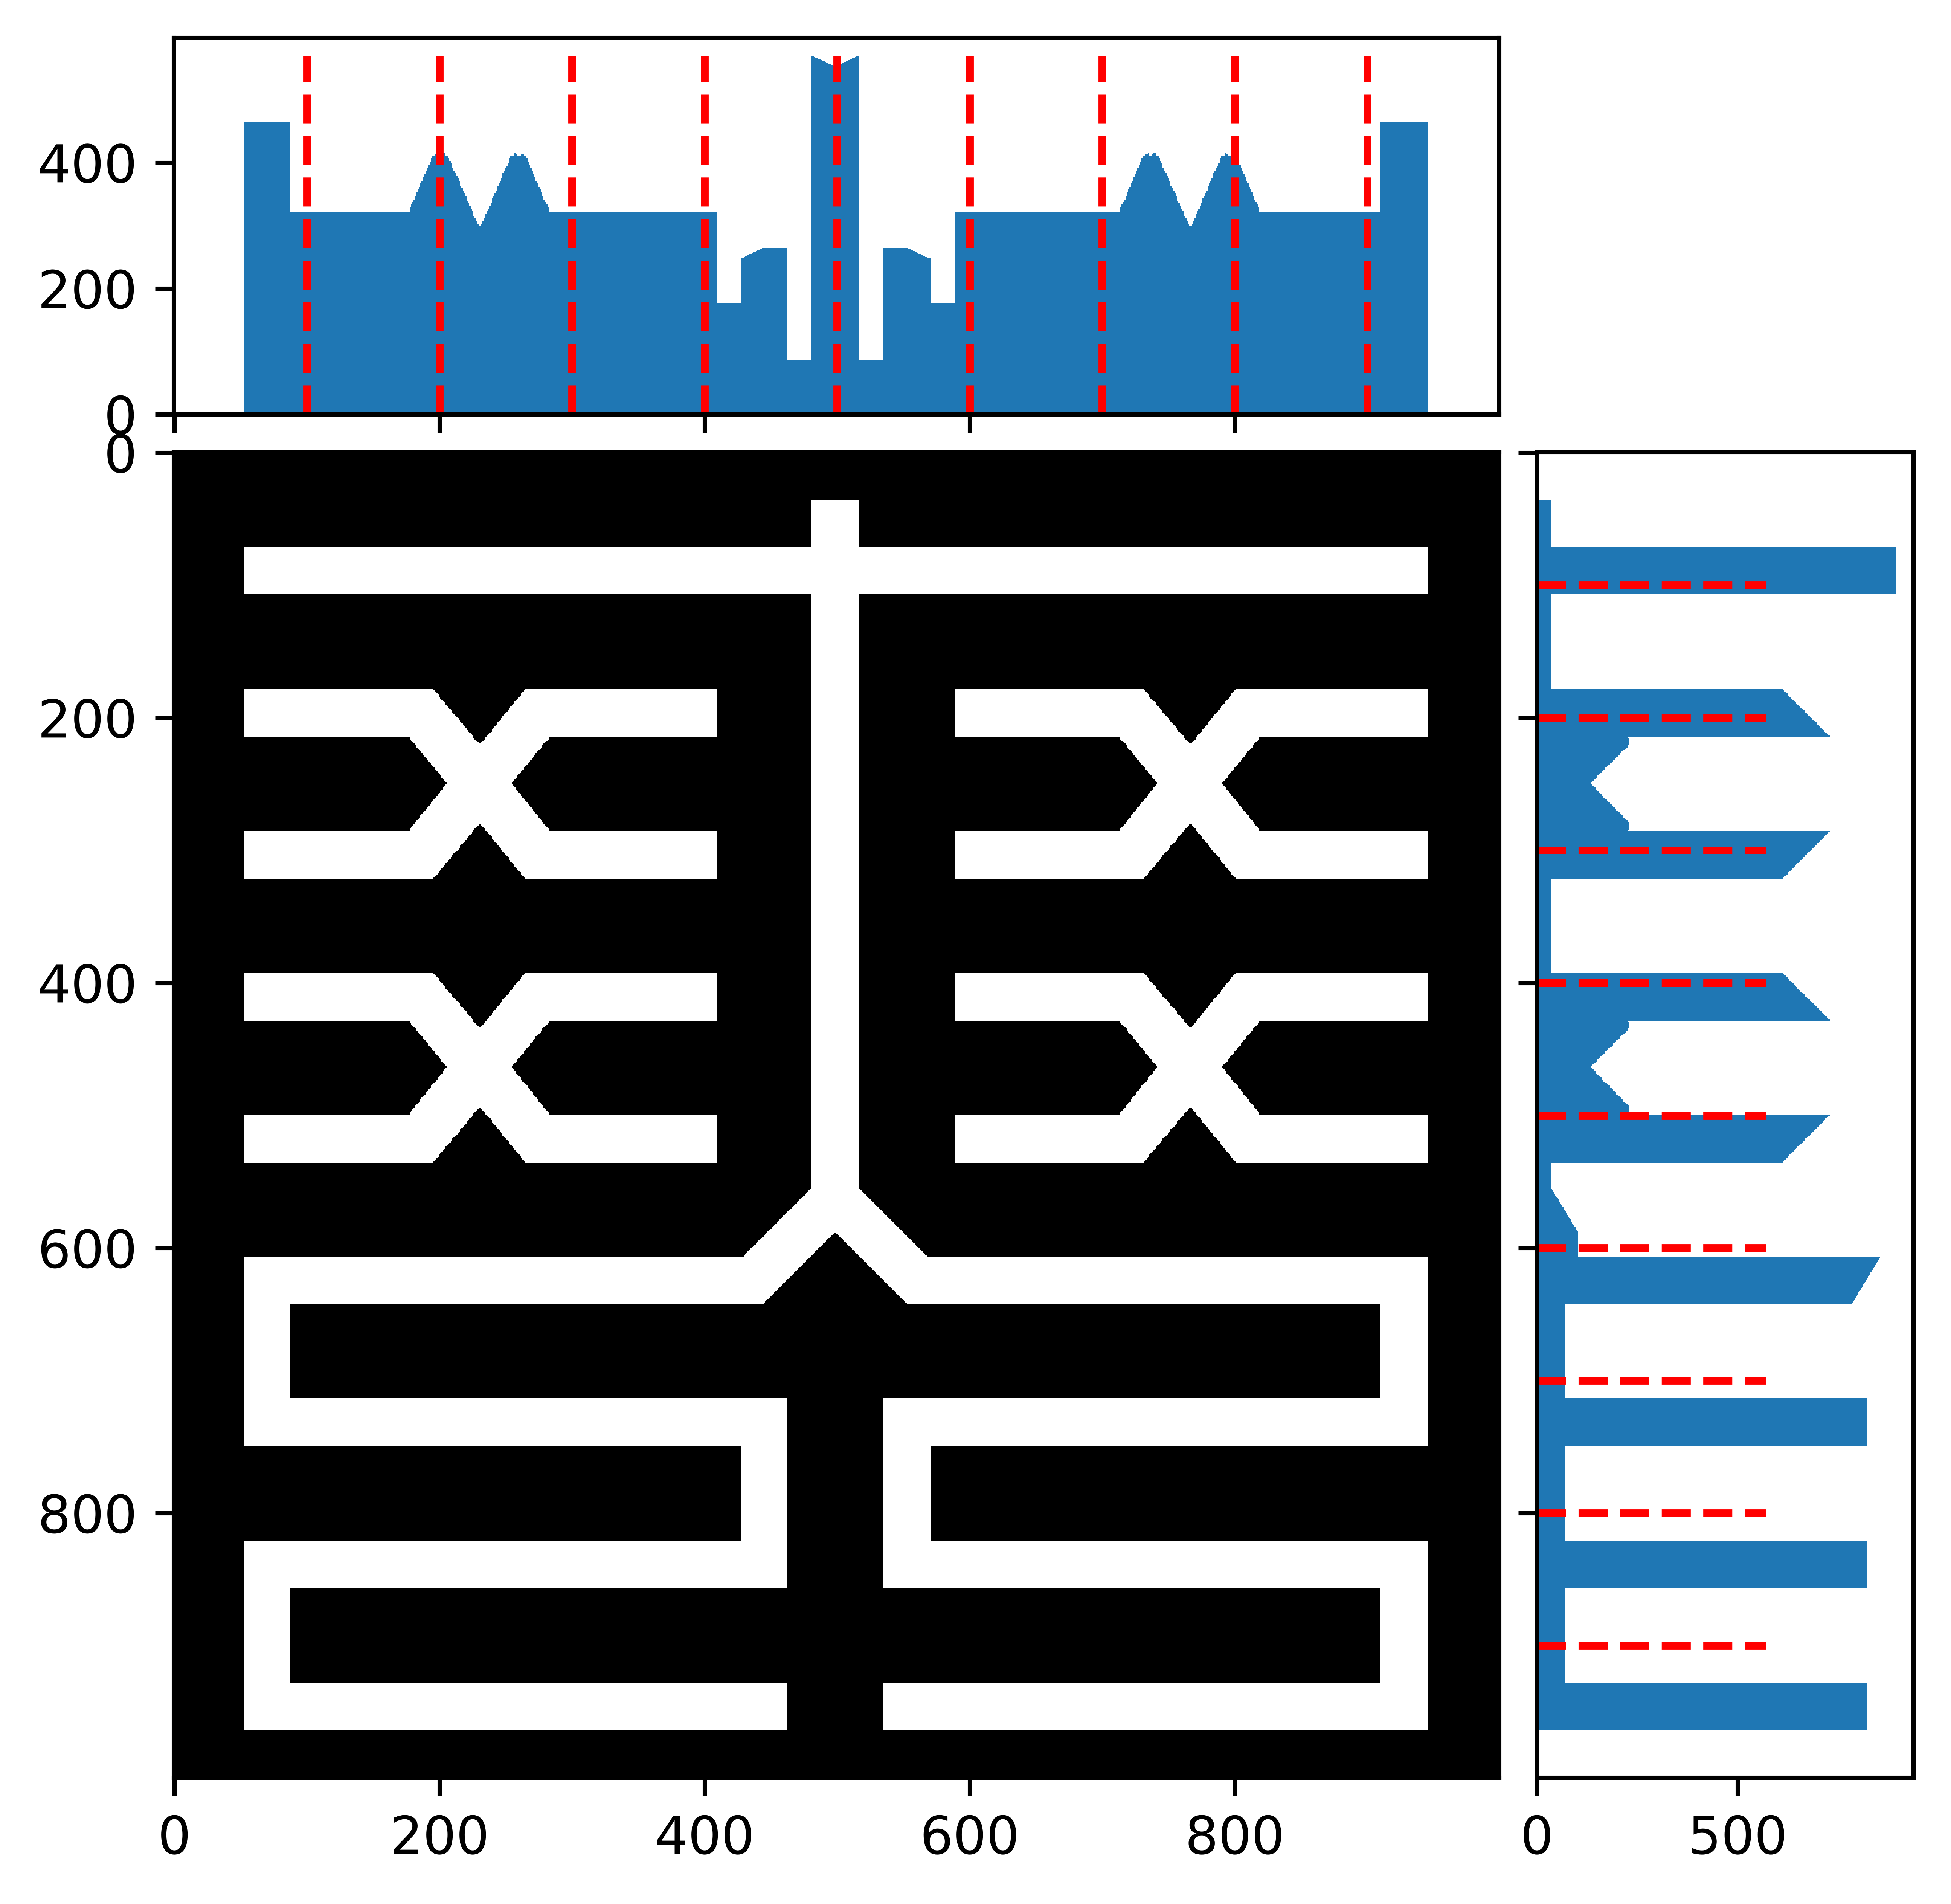

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

ys, xs = np.where(skeleton)

fig, ax = plt.subplots(figsize=(6, 6), dpi=1000)
ax.imshow(skeleton, cmap="gray")  # 默认 origin='upper'

divider = make_axes_locatable(ax)
ax_top = divider.append_axes("top", size=1.0, pad=0.1, sharex=ax)
ax_right = divider.append_axes("right", size=1.0, pad=0.1, sharey=ax)

# x histogram
hist_x = np.bincount(xs, minlength=skeleton.shape[1])
ref_x = np.linspace(0, skeleton.shape[1], 11)[1:-1]
ax_top.bar(np.arange(len(hist_x)), hist_x, width=1.0)
ax_top.vlines(
    ref_x,
    ymin=0,
    ymax=hist_x.max(),
    colors="r",
    linestyles="dashed",
)
ax_top.tick_params(labelbottom=False)

# y histogram
hist_y = np.bincount(ys, minlength=skeleton.shape[0])
ref_y = np.linspace(0, skeleton.shape[0], 11)[1:-1]
ax_right.barh(np.arange(len(hist_y)), hist_y, height=1.0)
ax_right.hlines(
    ref_y,
    xmin=0,
    xmax=hist_x.max(),
    colors="r",
    linestyles="dashed",
)

# 关键：由于 sharey，barh 已经与 imshow 对齐，不需要 invert_yaxis()

ax_right.tick_params(labelleft=False)

plt.show()

In [69]:
diag = xs - ys
hist_diag = np.bincount(diag - diag.min())
anti = xs + ys
hist_anti = np.bincount(anti)

plt.figure(figsize=(6, 6), dpi=len(hist_diag))
plt.bar(np.arange(len(hist_diag)), hist_diag)
plt.title("y=x direction")

Text(0.5, 1.0, 'y=x direction')

In [70]:
plt.figure(figsize=(6, 6), dpi=len(hist_anti))
plt.bar(np.arange(len(hist_anti)), hist_anti)
plt.title("y=-x direction")

Text(0.5, 1.0, 'y=-x direction')

In [124]:
grid_x = hist_x.argsort()[-9:]  # 最大的9个索引
grid_y = hist_y.argsort()[-9:]  # 最大的9个索引

In [125]:
ref_x

array([100., 200., 300., 400., 500., 600., 700., 800., 900.])

In [126]:
ref_x_to_grid_x = {}
grid_x_assigned = set()
for ref in ref_x:
    closest_grid = grid_x[np.argmin(np.abs(grid_x - ref))]
    if closest_grid not in grid_x_assigned:
        ref_x_to_grid_x[ref] = closest_grid
        grid_x_assigned.add(closest_grid)
    else:
        ref_x_to_grid_x[ref] = int(ref)
x_idx = np.asarray(list(ref_x_to_grid_x.values()), dtype=np.int32)

In [127]:
ref_x_to_grid_x

{np.float64(100.0): np.int64(481),
 np.float64(200.0): 200,
 np.float64(300.0): 300,
 np.float64(400.0): 400,
 np.float64(500.0): np.int64(513),
 np.float64(600.0): np.int64(516),
 np.float64(700.0): 700,
 np.float64(800.0): 800,
 np.float64(900.0): 900}

In [128]:
ref_y_to_grid_y = {}
grid_y_assigned = set()
for ref in ref_y:
    closest_grid = grid_y[np.argmin(np.abs(grid_y - ref))]
    if closest_grid not in grid_y_assigned:
        ref_y_to_grid_y[ref] = closest_grid
        grid_y_assigned.add(closest_grid)
    else:
        ref_y_to_grid_y[ref] = int(ref)
y_idx = np.asarray(list(ref_y_to_grid_y.values()), dtype=np.int32)


In [129]:
ref_y_to_grid_y

{np.float64(100.0): np.int64(102),
 np.float64(200.0): np.int64(103),
 np.float64(300.0): 300,
 np.float64(400.0): 400,
 np.float64(500.0): 500,
 np.float64(600.0): 600,
 np.float64(700.0): 700,
 np.float64(800.0): 800,
 np.float64(900.0): 900}

In [130]:
stroke_size = 1
hop_size = 1
w_strokes = 9
h_strokes = 9
W = w_strokes * stroke_size + hop_size * (w_strokes - 1)
H = h_strokes * stroke_size + hop_size * (h_strokes - 1)

In [131]:
import numpy as np


def fill_zeros_interp(arr):
    """
    使用 np.interp 进行插值（最简洁）
    """
    arr = arr.copy().astype(float)
    n = len(arr)

    # 找到非0点的索引和值
    valid_idx = np.where(arr != 0)[0]
    valid_vals = arr[valid_idx]

    if len(valid_idx) == 0:
        return arr

    # 对所有位置进行插值
    # 注意：np.interp 默认线性插值
    interpolated = np.interp(np.arange(n), valid_idx, valid_vals)

    # 只替换原来的0位置
    zero_mask = arr == 0
    arr[zero_mask] = interpolated[zero_mask]

    return arr


# # 示例
# arr = np.array([0, 0, 5, 0, 0, 0, 11, 0, 0, 20, 0])
# result = fill_zeros_interp(arr).astype(int)
# print(result)

In [132]:
x_idx_ = np.zeros(W, dtype=np.int32)
x_idx_[:: stroke_size + hop_size] = x_idx
x_idx_ = fill_zeros_interp(x_idx_).astype(np.int32)

In [133]:
y_idx_ = np.zeros(H, dtype=np.int32)
y_idx_[:: stroke_size + hop_size] = y_idx
y_idx_ = fill_zeros_interp(y_idx_).astype(np.int32)

In [134]:
downsampling_grid = skeleton[np.meshgrid(y_idx, x_idx)]

In [135]:
downsampling_grid = mask[np.meshgrid(y_idx_, x_idx_, indexing="ij")]

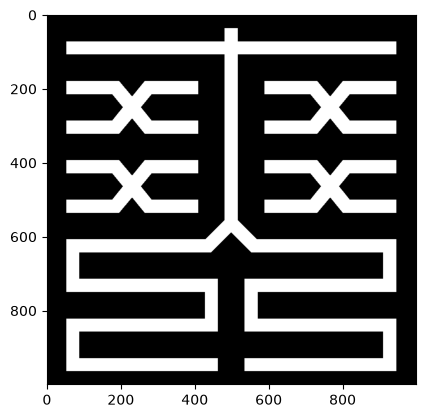

In [136]:
plt.imshow(skeleton, "gray")

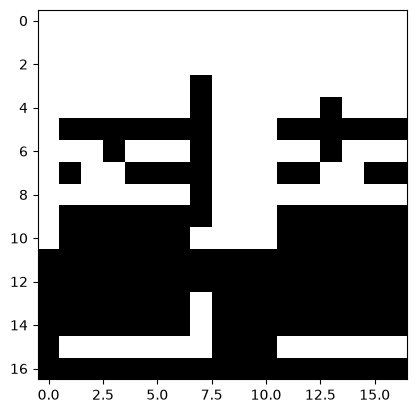

In [137]:
plt.imshow(downsampling_grid, "gray")